In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
print("Environment ready ✅")

Environment ready ✅


In [3]:
db_okrs = pd.DataFrame([
    {"objective": "Become the most reliable DB platform",
     "key_result": "Achieve 99.999% uptime (Five Nines)",
     "baseline": 99.9, "current": 99.95, "target": 99.999, "unit": "%", "lower_is_better": False},
    {"objective": "Become the most reliable DB platform",
     "key_result": "Reduce Mean Time to Recover (MTTR)",
     "baseline": 45, "current": 25, "target": 5, "unit": "mins", "lower_is_better": True},
    {"objective": "Become the most reliable DB platform",
     "key_result": "Increase automated failover success rate",
     "baseline": 85, "current": 92, "target": 100, "unit": "%", "lower_is_better": False},
])

def calc_progress(row):
    span = row.target - row.baseline
    done = row.current - row.baseline
    pct = 0 if span == 0 else (done / span) * 100
    return round(max(0, min(100, pct)), 1)

db_okrs["progress_pct"] = db_okrs.apply(calc_progress, axis=1)
db_okrs

,objective,key_result,baseline,current,target,unit,lower_is_better,progress_pct
0,Become the most reliable DB platform,Achieve 99.999% uptime (Five Nines),99.9,99.95,99.999,%,False,50.5
1,Become the most reliable DB platform,Reduce Mean Time to Recover (MTTR),45.0,25.00,5.000,mins,True,50.0
2,Become the most reliable DB platform,Increase automated failover success rate,85.0,92.00,100.000,%,False,46.7


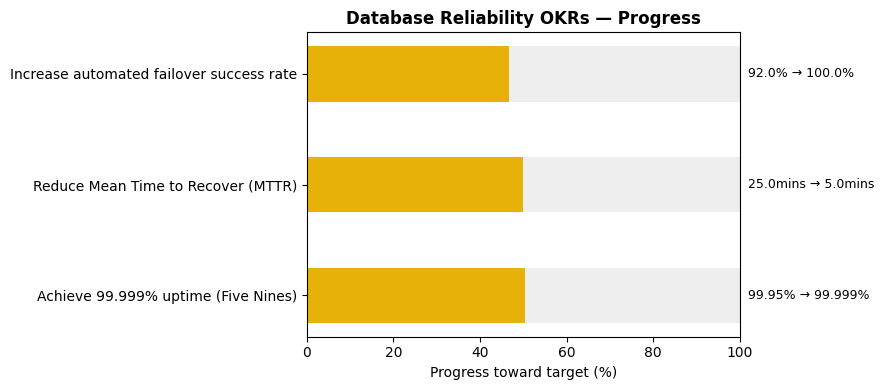

In [4]:
fig1, ax1 = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(db_okrs))
colors = ["#2C5F2D" if p >= 70 else "#E7B10A" if p >= 40 else "#B85042" for p in db_okrs.progress_pct]

ax1.barh(y_pos, db_okrs.progress_pct, color=colors, height=0.5, zorder=1)
ax1.barh(y_pos, 100, color="#EEEEEE", height=0.5, zorder=0)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(db_okrs.key_result)
ax1.set_xlim(0, 100)
ax1.set_xlabel("Progress toward target (%)")
ax1.set_title("Database Reliability OKRs — Progress", fontsize=12, fontweight="bold")

for i, (p, cur, tgt, unit) in enumerate(zip(db_okrs.progress_pct, db_okrs.current, db_okrs.target, db_okrs.unit)):
    ax1.text(102, i, f"{cur}{unit} → {tgt}{unit}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
db_roadmap = pd.DataFrame([
    {"initiative": "Multi-region replication", "key_result": "Achieve 99.999% uptime (Five Nines)",
     "start": "2026-01-01", "end": "2026-03-15", "confidence": "High"},
    {"initiative": "Chaos Engineering suite", "key_result": "Achieve 99.999% uptime (Five Nines)",
     "start": "2026-02-15", "end": "2026-05-01", "confidence": "Medium"},
    {"initiative": "Predictive healing AI", "key_result": "Reduce Mean Time to Recover (MTTR)",
     "start": "2026-03-01", "end": "2026-06-15", "confidence": "Low"},
    {"initiative": "Zero-touch recovery bot", "key_result": "Reduce Mean Time to Recover (MTTR)",
     "start": "2026-05-15", "end": "2026-08-01", "confidence": "Medium"},
    {"initiative": "Auto-scaling shard health", "key_result": "Increase automated failover success rate",
     "start": "2026-07-01", "end": "2026-10-01", "confidence": "High"},
])
db_roadmap["start"] = pd.to_datetime(db_roadmap["start"])
db_roadmap["end"] = pd.to_datetime(db_roadmap["end"])
db_roadmap["duration_days"] = (db_roadmap["end"] - db_roadmap["start"]).dt.days
db_roadmap

,initiative,key_result,start,end,confidence,duration_days
0,Multi-region replication,Achieve 99.999% uptime (Five Nines),2026-01-01,2026-03-15,High,73
1,Chaos Engineering suite,Achieve 99.999% uptime (Five Nines),2026-02-15,2026-05-01,Medium,75
2,Predictive healing AI,Reduce Mean Time to Recover (MTTR),2026-03-01,2026-06-15,Low,106
3,Zero-touch recovery bot,Reduce Mean Time to Recover (MTTR),2026-05-15,2026-08-01,Medium,78
4,Auto-scaling shard health,Increase automated failover success rate,2026-07-01,2026-10-01,High,92


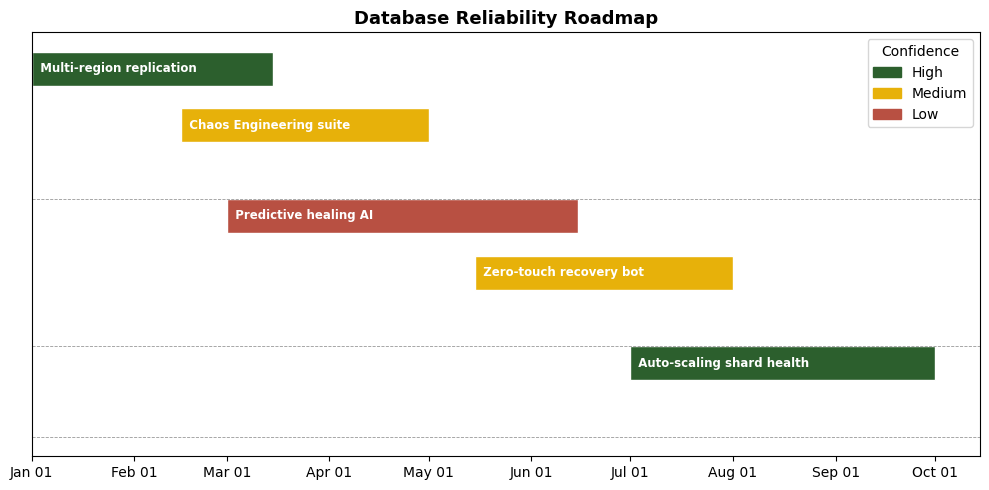

In [7]:
conf_color = {"High": "#2C5F2D", "Medium": "#E7B10A", "Low": "#B85042"}
krs = db_roadmap["key_result"].unique()
fig2, ax2 = plt.subplots(figsize=(10, 5))

y = 0
for kr in krs:
    rows = db_roadmap[db_roadmap["key_result"] == kr]
    for _, r in rows.iterrows():
        ax2.barh(y, r.duration_days, left=r.start, height=0.6, color=conf_color[r.confidence], edgecolor="white")
        ax2.text(r.start, y, f"  {r.initiative}", va="center", ha="left", fontsize=8.5, color="white", fontweight="bold")
        y += 1
    y += 0.6
    ax2.axhline(y - 0.3, color="#999999", linewidth=0.6, linestyle="--")

ax2.set_yticks([]); ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.set_title("Database Reliability Roadmap", fontsize=13, fontweight="bold")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in conf_color.values()]
ax2.legend(handles, conf_color.keys(), title="Confidence", loc="upper right")
plt.tight_layout()
plt.show()